# NZ Wave Hindcast Storm Classification & Analysis

# Objective and Storm Definition
Objective

This analysis identifies and characterises storm events in the NZ Wave Hindcast dataset using physically meaningful thresholds. The goal is to quantify storm frequency, duration, intensity, and direction, providing a model-based storm climatology suitable for comparison with buoy observations and coastal erosion studies.

⚙️ Storm Definition

A storm event is defined as:

Significant Wave Height (Hs) > 2.5 m

Minimum storm duration: 3 days (72 hours)

Minimum storm recurrence interval: 24 hours between consecutive storms

For exploratory purposes, storms lasting ≥1 day and ≥2 days are also analysed.

# Import Libraries and Load Cleaned Hindcast Dataset

We begin by loading the already cleaned NZ Wave Hindcast dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
file_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\Nz_Hindcast_clean.csv"

df = pd.read_csv(file_path, parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df.head()


,datetime,lat,lng,RTpeak,FSpr,Dir,Hsig,is_storm,storm_event_id
0,1993-01-01 00:00:00+00:00,-44.207073,173.28284,13.1754,0.374705,109.029,1.91179,False,1
1,1993-01-01 03:00:00+00:00,-44.207073,173.28284,13.1754,0.374705,109.029,1.91179,False,1
2,1993-01-01 06:00:00+00:00,-44.207073,173.28284,13.1754,0.373431,108.571,1.90887,False,1
3,1993-01-01 09:00:00+00:00,-44.207073,173.28284,11.8843,0.378315,108.256,1.90706,False,1
4,1993-01-01 12:00:00+00:00,-44.207073,173.28284,11.8843,0.382407,111.118,1.91703,False,1


# Variable Overview and Renaming
Key Variables Used

To maintain consistency with ECAN buoy analysis:

Hindcast Variable	Meaning
Hsig	Significant wave height (m)
RTpeak	Peak wave period (s)
Dir	Mean wave direction (degrees)
FSpr	Directional spread
datetime	Time (UTC)
We rename Hsig to Hs for consistency.

In [3]:
df = df.rename(columns={"Hsig": "Hs", "Dir": "Dp"})


# Cleaned Time Series Overview
Significant Wave Height vs Time

This plot provides context for storm detection and confirms the temporal continuity of the hindcast data.

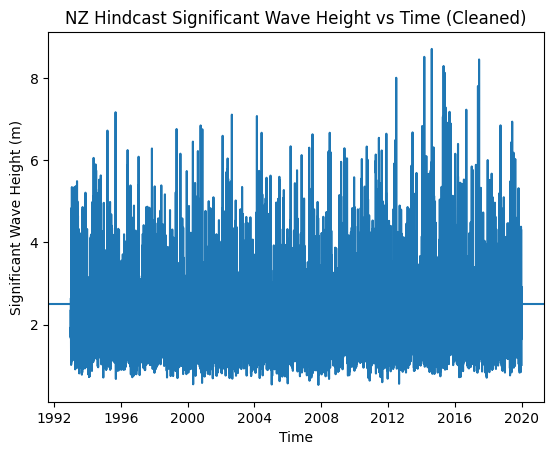

In [4]:
plt.figure()
plt.plot(df["datetime"], df["Hs"])
plt.axhline(2.5)
plt.xlabel("Time")
plt.ylabel("Significant Wave Height (m)")
plt.title("NZ Hindcast Significant Wave Height vs Time (Cleaned)")
plt.show()

# Storm Identification Logic
Storm Detection Method

Identify all time steps where Hs > 2.5 m

Group consecutive exceedances

Compute storm duration, peak intensity, and mean direction

Enforce 24-hour minimum recurrence interval

In [5]:
threshold = 2.5

df["storm_flag"] = df["Hs"] > threshold
df["storm_group"] = (df["storm_flag"] != df["storm_flag"].shift()).cumsum()

storms = (
    df[df["storm_flag"]]
    .groupby("storm_group")
    .agg(
        start_time=("datetime", "min"),
        end_time=("datetime", "max"),
        duration_hours=("datetime", lambda x: (x.max() - x.min()).total_seconds() / 3600),
        peak_Hs=("Hs", "max"),
        mean_direction=("Dp", "mean")
    )
    .reset_index(drop=True)
)

# Enforce 24-hour minimum storm recurrence interval
storms = storms.sort_values("start_time")
storms = storms[
    storms["start_time"].diff().fillna(pd.Timedelta(hours=25)) >= pd.Timedelta(hours=24)
]

# Storm Duration Classification

We classify storms by duration for comparative analysis:

≥1 day (24 h)

≥2 days (48 h)

≥3 days (72 h) ← primary storm definition

In [7]:
storms_1d = storms[storms["duration_hours"] >= 24]
storms_2d = storms[storms["duration_hours"] >= 48]
storms_3d = storms[storms["duration_hours"] >= 72]

# Storms with Hs > 2.5 m by Duration 

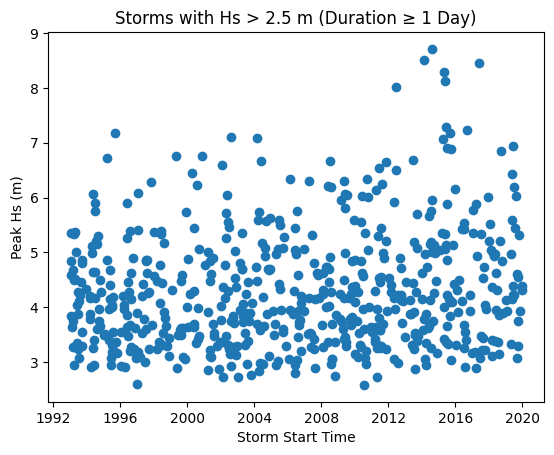

In [8]:
plt.figure()
plt.scatter(storms_1d["start_time"], storms_1d["peak_Hs"])
plt.xlabel("Storm Start Time")
plt.ylabel("Peak Hs (m)")
plt.title("Storms with Hs > 2.5 m (Duration ≥ 1 Day)")
plt.show()

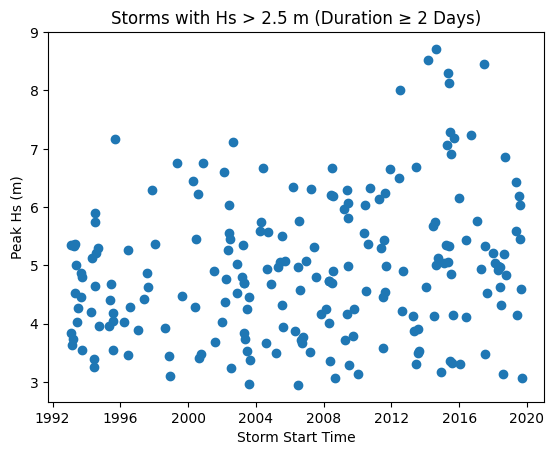

In [9]:
plt.figure()
plt.scatter(storms_2d["start_time"], storms_2d["peak_Hs"])
plt.xlabel("Storm Start Time")
plt.ylabel("Peak Hs (m)")
plt.title("Storms with Hs > 2.5 m (Duration ≥ 2 Days)")
plt.show()

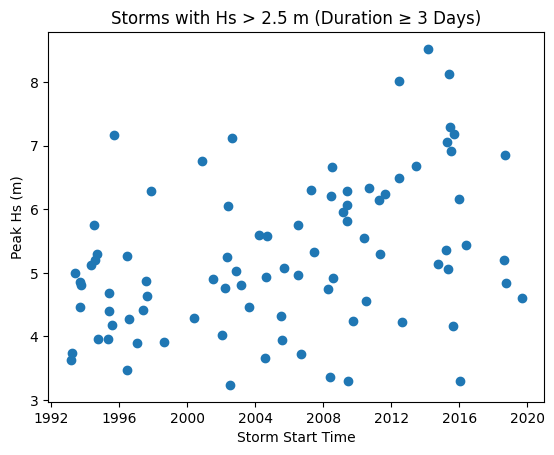

In [10]:
plt.figure()
plt.scatter(storms_3d["start_time"], storms_3d["peak_Hs"])
plt.xlabel("Storm Start Time")
plt.ylabel("Peak Hs (m)")
plt.title("Storms with Hs > 2.5 m (Duration ≥ 3 Days)")
plt.show()

# Peak Significant Wave Height Distribution
Storm Intensity Distribution

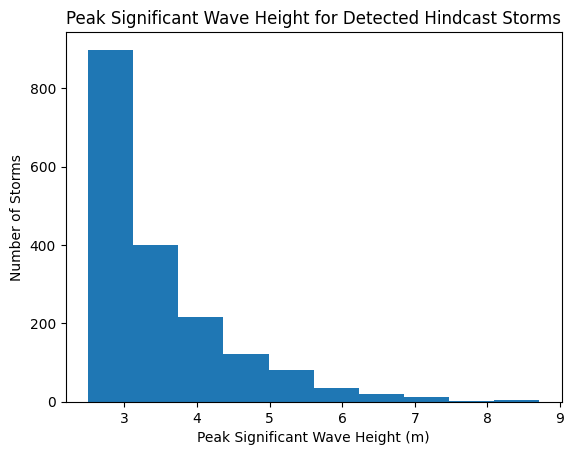

In [12]:
plt.figure()
plt.hist(storms["peak_Hs"])
plt.xlabel("Peak Significant Wave Height (m)")
plt.ylabel("Number of Storms")
plt.title("Peak Significant Wave Height for Detected Hindcast Storms")
plt.show()

# Storm Direction vs Peak Wave Height
Directional Characteristics of Storms

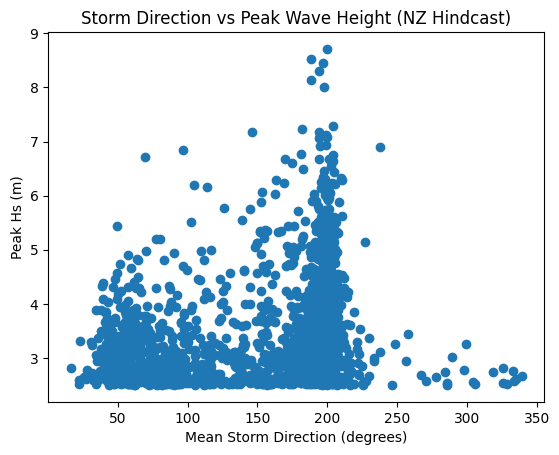

In [14]:
plt.figure()
plt.scatter(storms["mean_direction"], storms["peak_Hs"])
plt.xlabel("Mean Storm Direction (degrees)")
plt.ylabel("Peak Hs (m)")
plt.title("Storm Direction vs Peak Wave Height (NZ Hindcast)")
plt.show()

# Storm Duration vs Intensity
Duration–Intensity Relationship

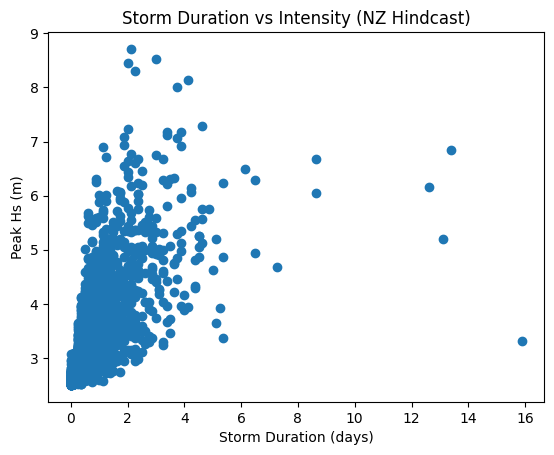

In [16]:
plt.figure()
plt.scatter(storms["duration_hours"] / 24, storms["peak_Hs"])
plt.xlabel("Storm Duration (days)")
plt.ylabel("Peak Hs (m)")
plt.title("Storm Duration vs Intensity (NZ Hindcast)")
plt.show()

# Clustered Storm Types
Storm Typology Using Clustering

Storms are clustered using:

Peak Hs (intensity)

Mean direction

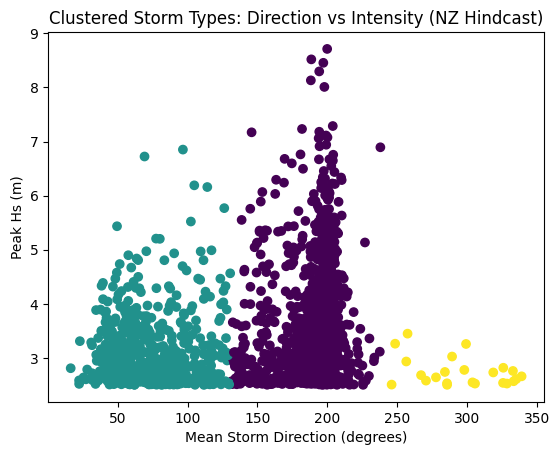

In [17]:
X = storms[["peak_Hs", "mean_direction"]].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
storms.loc[X.index, "cluster"] = kmeans.fit_predict(X)

plt.figure()
plt.scatter(
    storms["mean_direction"],
    storms["peak_Hs"],
    c=storms["cluster"]
)
plt.xlabel("Mean Storm Direction (degrees)")
plt.ylabel("Peak Hs (m)")
plt.title("Clustered Storm Types: Direction vs Intensity (NZ Hindcast)")
plt.show()